**LIBRARIES & INITIAL LOAD**

In [51]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.style.use('ggplot')
multifigs_size = (12, 4)

**DATASET OVERVIEW**

This dataset contains 5,110 comprehensive clinical and lifestyle records of patient assessments adapted for automated cardiovascular and neurological risk analysis.
* gender: Biological sex recorded during examination; categories include Female (Nữ) and Male (Nam).
* age: Chronological age of the patient in years, a baseline for age-related arterial degradation.
* hypertension: Diagnostic indicator for chronic high blood pressure (0: No, 1: Yes).
* heart_disease: Presence of cardiovascular complications or ischemic heart disease (0: No, 1: Yes).
* ever_married: Social lifestyle status profiling marital history; classified as Yes (Đã kết hôn) or No (Chưa).
* work_type: Occupational domain reflecting work environment dynamics; Private (Tư nhân), Self-employed (Tự kinh doanh), Govt_job (Nhà nước), Children (Trẻ em), or Never_worked.
* Residence_type: Geographic classification of primary residential zone; Urban (Thành thị) or Rural (Nông thôn).
* avg_glucose_level: Continuous physiological measurement of average blood glucose concentration (in $mg/dL$).
* bmi: Body Mass Index reflecting physical body mass configuration and adiposity stress ($kg/m^2$).
* smoking_status: Behavioral lifestyle metric detailing tobacco consumption; formerly smoked, never smoked, smokes, or Unknown.
* stroke: The binary target variable representing clinical occurrence of a cerebrovascular accident (0: No, 1: Yes).

In [2]:
original_df = pd.read_csv('healthcare-dataset-stroke-data.csv')
original_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


**INFORMATION OF STROKE PREDICTION DATASET**

In [3]:
original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


We can see that gender, ever_married, work_type, Residence_type, and smoking_status are structural categorical variables (object). Conversely, age, avg_glucose_level, and bmi are continuous numerical attributes (float64).

However, hypertension and heart_disease are currently identified as numerical integers (int64), let's explicitly look at their unique values:

In [4]:
print("Unique hypertension values:", set(original_df['hypertension']))
print("Unique heart_disease values:", set(original_df['heart_disease']))

Unique hypertension values: {0, 1}
Unique heart_disease values: {0, 1}


The unique values for both metrics are strictly restricted to 0 and 1. These numbers represent discrete, binary clinical conditions (0: Absent, 1: Present) rather than continuous, fluid numerical measurements.

Therefore, to prevent the machine learning models from assuming an incorrect mathematical ranking or continuous scale, it is highly critical to treat hypertension and heart_disease as categorical features and explicitly cast their data types.

In [5]:
original_df['hypertension'] = original_df['hypertension'].astype('object')
original_df['heart_disease'] = original_df['heart_disease'].astype('object')
original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   object 
 4   heart_disease      5110 non-null   object 
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(2), object(7)
memory usage: 479.2+ KB


Next, let's find out more information about the numerical variables such as age, avg_glucose_level, and bmi in the dataset below.

In [7]:
original_df[['age', 'avg_glucose_level', 'bmi']].describe()

,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,4909.000000
mean,43.226614,106.147677,28.893237
std,22.612647,45.283560,7.854067
min,0.080000,55.120000,10.300000
25%,25.000000,77.245000,23.500000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,33.100000
max,82.000000,271.740000,97.600000


age: Spans a wide range from 0.08 to 82.00 years old, with an average of 43.23. This allows the model to capture stroke risks across different age groups.

avg_glucose_level: Varies greatly from 55.12 to 271.74 $mg/dL$. The average (106.15) is higher than the median (91.89), showing that the data includes many patients with high blood sugar or diabetes.

bmi: Scales from 10.30 to an extreme 97.60 $kg/m^2$. The median sits at 28.10, but the maximum ceiling is exceptionally high, strongly indicating a right-skewed distribution with major outliers.

**DATA CLEANING**

Clone a copy of the original dataset to keep it separated.

In [9]:
df = original_df.copy()

**DATA DUPLICATION**

Firstly, we'll find whether the dataset has any duplication:

In [10]:
dup_ind = df.duplicated()
df[dup_ind]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


The check returns an empty DataFrame, indicating that there are 0 duplicate records in this dataset. Since the data is inherently unique and clean right from the collection phase, no drop operations are required.

Therefore, we can safely proceed directly to the missing data evaluation.

**MISSING DATA**

Let's check the percent of missing data:

In [11]:
df.isnull().sum() * 100 / df.shape[0]

,0
id,0.000000
gender,0.000000
age,0.000000
hypertension,0.000000
heart_disease,0.000000
ever_married,0.000000
work_type,0.000000
Residence_type,0.000000
avg_glucose_level,0.000000
bmi,3.933464


The check reveals that the bmi feature contains approximately 3.93% missing records (201 null values), while all other structural features are fully complete.

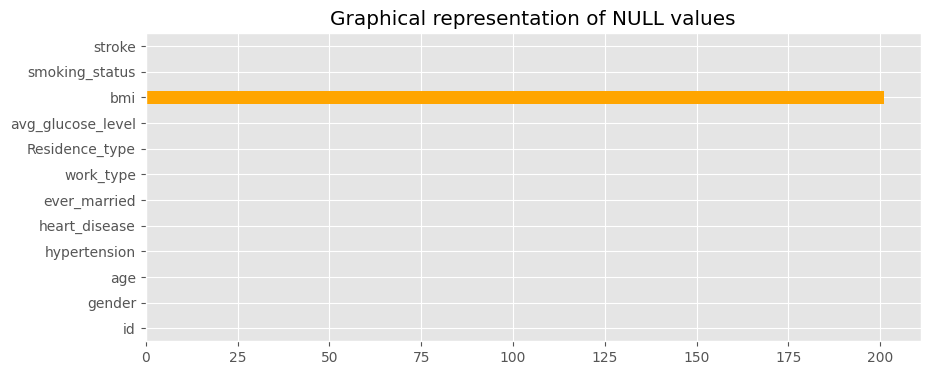

In [12]:
plt.figure(figsize=(10, 4))
df.isna().sum().plot.barh(color='orange')
plt.title("Graphical representation of NULL values")
plt.show()

Since the bmi distribution is heavily right-skewed with prominent outliers (as analyzed in the statistical overview), we will handle this missing data by using the Median imputation method during the preprocessing pipeline to ensure robustness against extreme values.

**OUTLIER DETECTION**

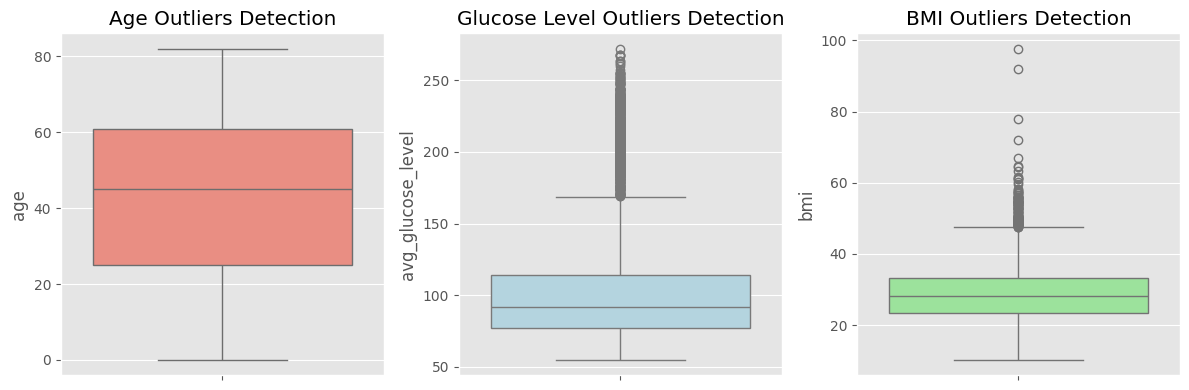

In [13]:
fig, axs = plt.subplots(ncols=3, figsize=multifigs_size)
sns.boxplot(y=df['age'], ax=axs[0], color='salmon')
axs[0].set_title('Age Outliers Detection')

sns.boxplot(y=df['avg_glucose_level'], ax=axs[1], color='lightblue')
axs[1].set_title('Glucose Level Outliers Detection')

sns.boxplot(y=df['bmi'], ax=axs[2], color='lightgreen')
axs[2].set_title('BMI Outliers Detection')

plt.tight_layout()
plt.show()

Handling Strategy for Clinical Outliers

In [14]:
num_cols = ['age', 'avg_glucose_level', 'bmi']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"Total outliers detected in {col}: {outliers_count}")

Total outliers detected in age: 0
Total outliers detected in avg_glucose_level: 627
Total outliers detected in bmi: 110


**EXPLORATORY DATA ANALYSIS**

The dataset contains exactly 5,110 observations for exploratory analysis, preserving all physiological records to protect vital pathological signals since no destructive row removal was performed during the outlier evaluation phase.
* Categorical variables: gender, hypertension, heart_disease, ever_married, work_type, Residence_type, smoking_status

* Numerical variables: age, avg_glucose_level, bmi

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   object 
 4   heart_disease      5110 non-null   object 
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(2), object(7)
memory usage: 479.2+ KB


To better visualize and analyze clinical structural behaviors, we engineer grouped categorical features through a statistical binning process based on medical baselines.

First, for the demographic timeline, we classify the chronological age of the patients into distinct age_groups reflecting different life stages of cardiovascular development:
* Children: $\le 18$ years old (early developmental stage)
* Adults: $18 < \text{age} \le 50$ years old (active working force profile)
* Seniors: $> 50$ years old (higher clinical vulnerability phase)

In [16]:
def categorize_age(row):
    if row["age"] <= 18:
        return "Children"
    elif row["age"] <= 50:
        return "Adults"
    else:
        return "Seniors"

df['age_groups'] = df.apply(categorize_age, axis=1)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_groups
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Seniors
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,Seniors
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Seniors
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Adults
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Seniors


Next, for physical body mass configurations, we categorize the actual bmi metrics into bmi_groups using standard World Health Organization (WHO) international automotive health benchmarks:
* Underweight: $< 18.5$ $kg/m^2$
* Normal: $18.5 \le \text{bmi} < 25$ $kg/m^2$
* Overweight: $25 \le \text{bmi} < 30$ $kg/m^2$
* Obese: $\le 30$ $kg/m^2$
* Unknown: Missing values placeholder (to be imputed inside the pipeline later)

In [17]:
def categorize_bmi(row):
    if pd.isna(row["bmi"]):
        return "Unknown"
    elif row["bmi"] < 18.5:
        return "Underweight"
    elif row["bmi"] < 25:
        return "Normal"
    elif row["bmi"] < 30:
        return "Overweight"
    else:
        return "Obese"

df['bmi_groups'] = df.apply(categorize_bmi, axis=1)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_groups,bmi_groups
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Seniors,Obese
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,Seniors,Unknown
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Seniors,Obese
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Adults,Obese
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Seniors,Normal


Next, we'll observe the distribution of our critical prediction target variable: stroke.

**PREDICTION VARIABLE**

We'll plot the distribution of our target prediction variable: stroke.

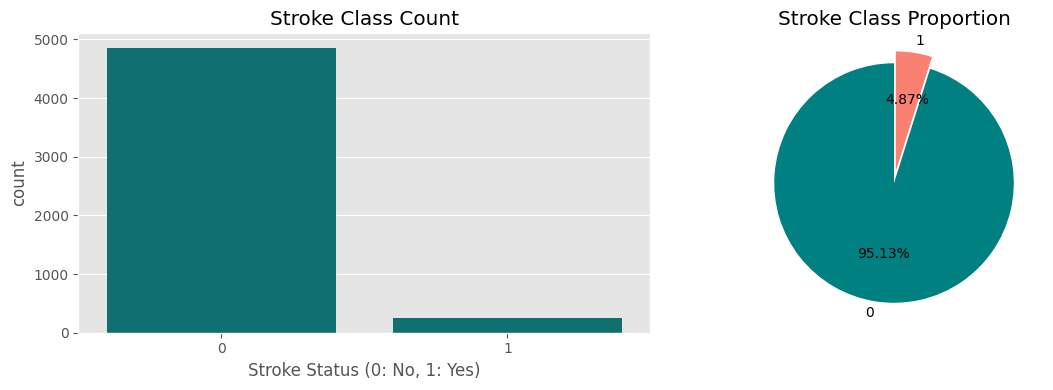

In [19]:
fig, axs = plt.subplots(ncols=2, figsize=multifigs_size)

sns.countplot(x=df['stroke'], ax=axs[0], color='teal')
axs[0].set_title('Stroke Class Count')
axs[0].set_xlabel('Stroke Status (0: No, 1: Yes)')

df['stroke'].value_counts().plot.pie(ax=axs[1], autopct='%1.2f%%', startangle=90, colors=['teal', 'salmon'], explode=[0, 0.1])
axs[1].set_title('Stroke Class Proportion')
axs[1].set_ylabel('')

plt.tight_layout()
plt.show()

This target variable displays a severe class imbalance. The data reveals that only 4.87% of the recorded patients experienced a stroke (Class 1), while the remaining 95.13% represent healthy individuals (Class 0). This massive structural disparity indicates that standard model training will be highly biased toward the majority class, proving why we must implement advanced over-sampling techniques (like SMOTE) later in our preprocessing phase

Next, let's analyze the categorical variables.

**CATEGORICAL VARIABLES**

Extract dataset with categorical variables for data visualization

In [20]:
cat_df = df.select_dtypes(include="object").copy()
cat_df.head()

,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,age_groups,bmi_groups
0,Male,0,1,Yes,Private,Urban,formerly smoked,Seniors,Obese
1,Female,0,0,Yes,Self-employed,Rural,never smoked,Seniors,Unknown
2,Male,0,1,Yes,Private,Rural,never smoked,Seniors,Obese
3,Female,0,0,Yes,Private,Urban,smokes,Adults,Obese
4,Female,1,0,Yes,Self-employed,Rural,never smoked,Seniors,Normal


Categorical variables view with bar charts:

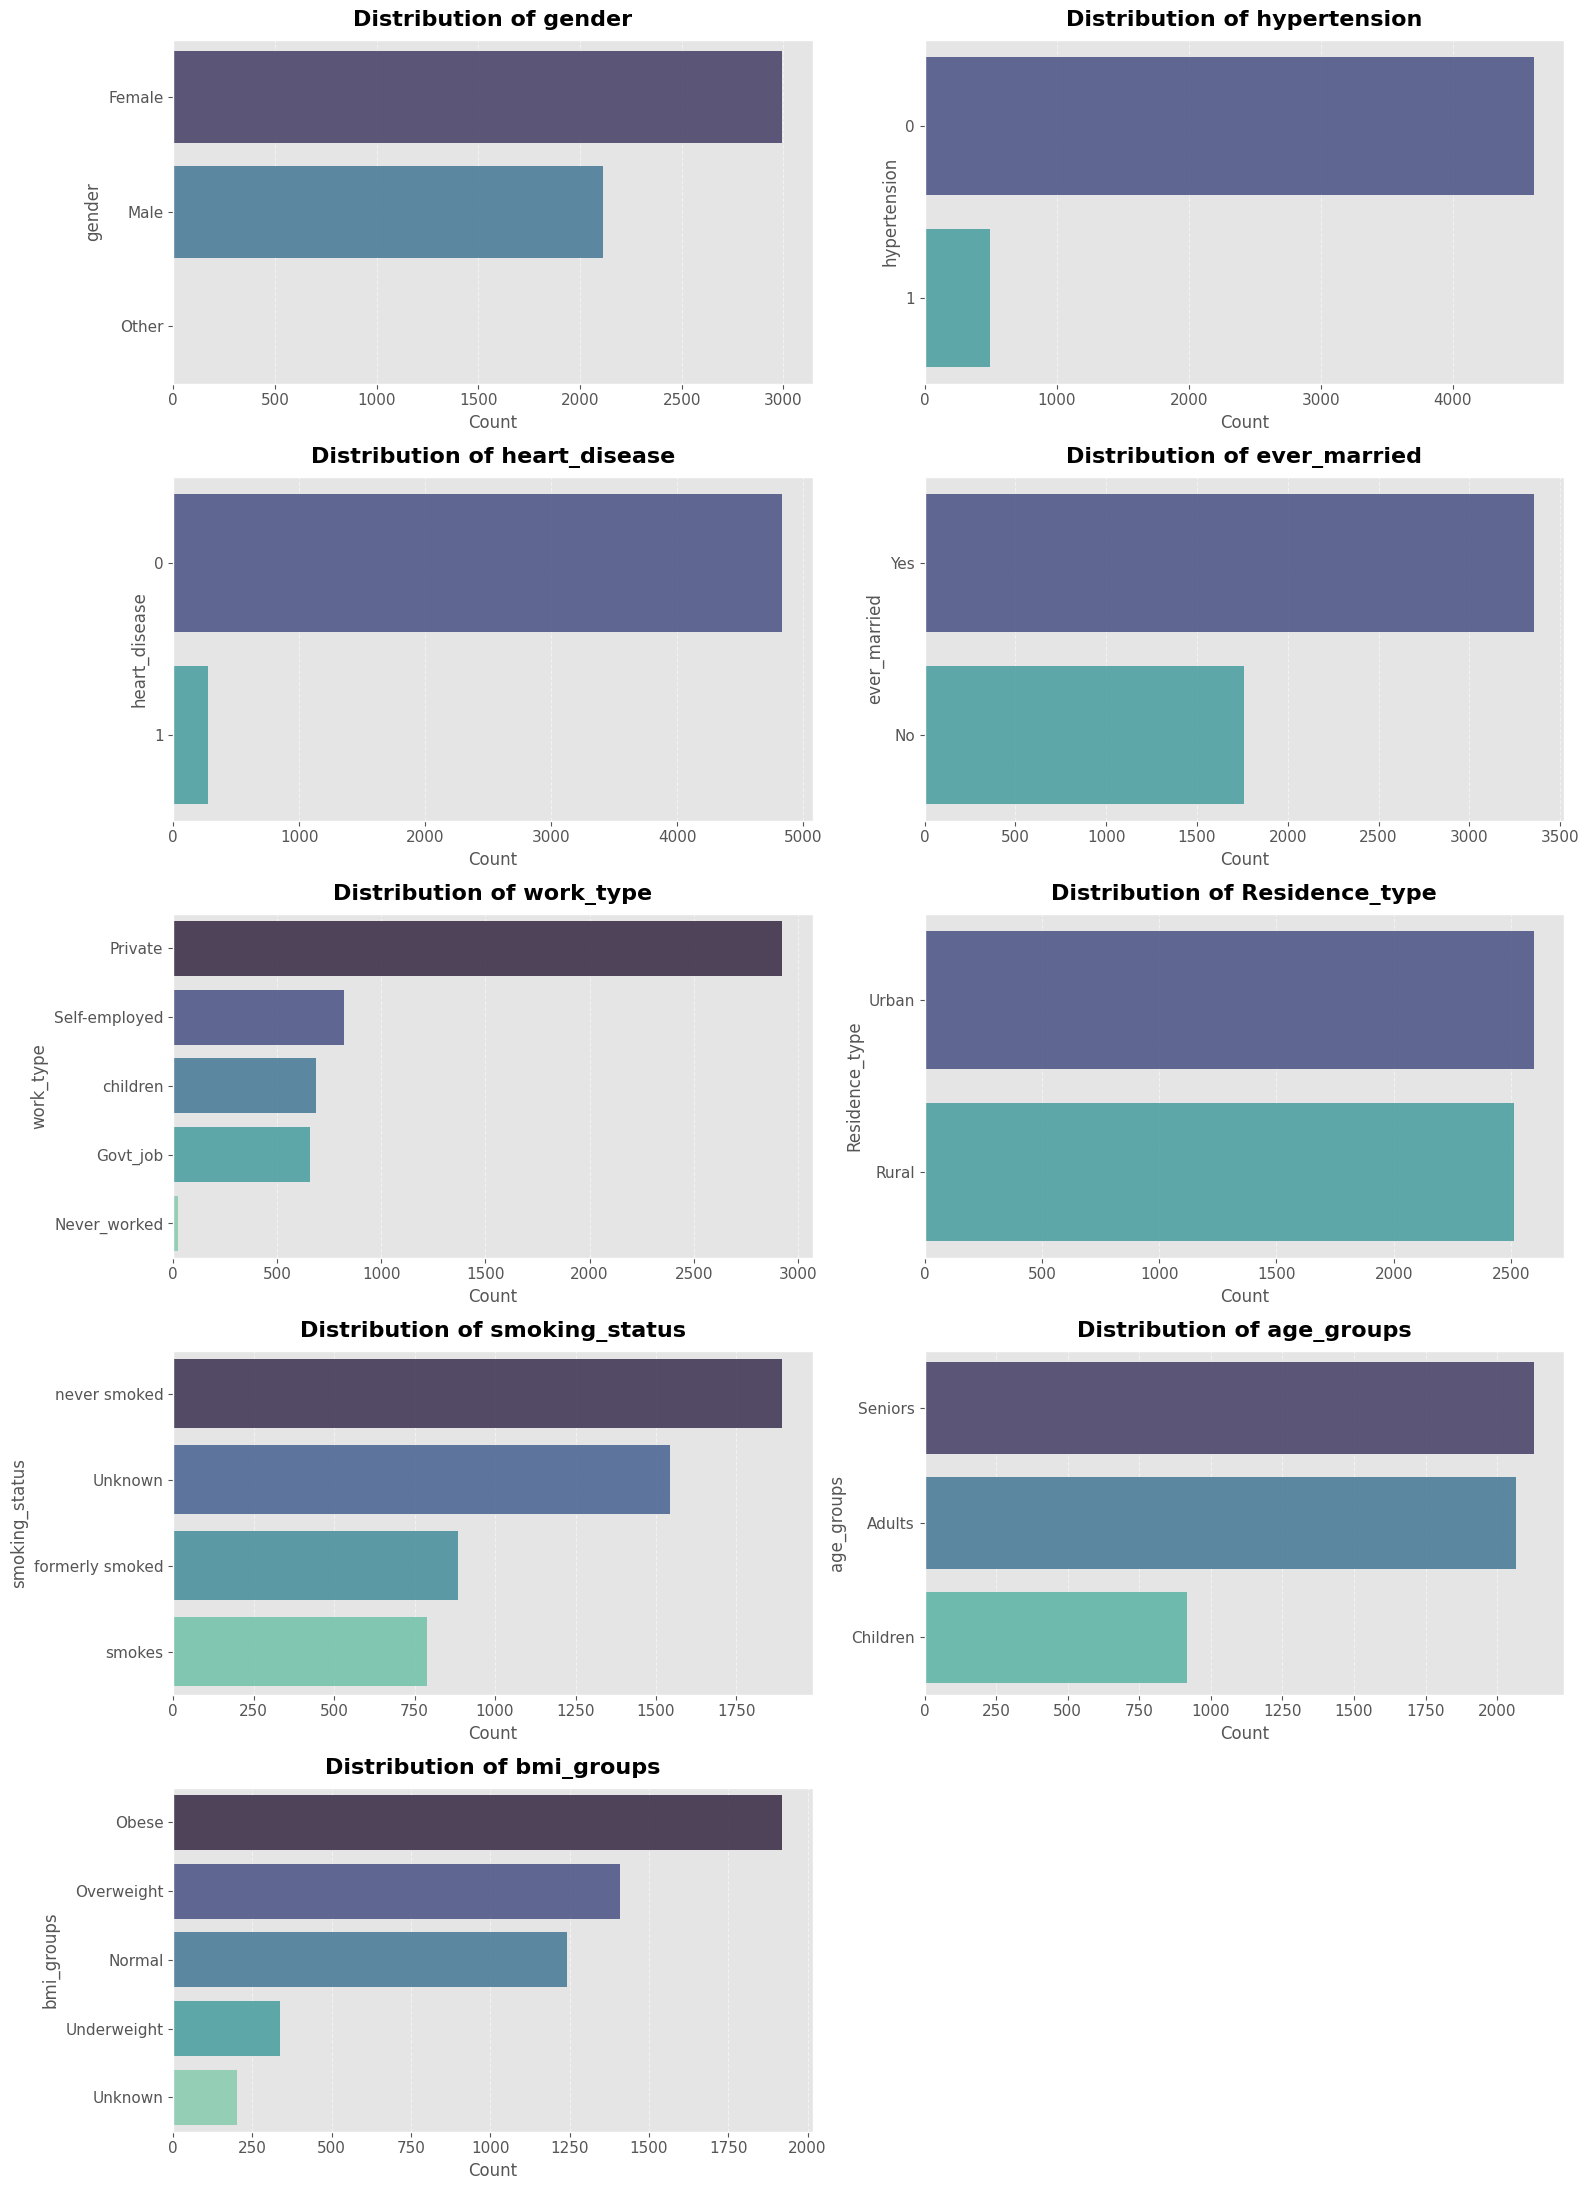

In [23]:
cols_to_plot = list(cat_df.columns)

num_plot = len(cols_to_plot)
num_cols = min(num_plot, 2)
num_rows = int(num_plot / num_cols) + (1 if num_plot % num_cols != 0 else 0)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 22))
list_axes = list(axes.flat) if isinstance(axes, np.ndarray) else [axes]

for index, col in enumerate(cols_to_plot):
    sns.countplot(
        ax=list_axes[index],
        y=cat_df[col],
        order=cat_df[col].value_counts().index,
        palette='mako',
        alpha=0.85
    )

    list_axes[index].set_title(f'Distribution of {col}', fontsize=16, fontweight='bold', pad=10)
    list_axes[index].set_xlabel('Count', fontsize=12)
    list_axes[index].set_ylabel(col, fontsize=12)
    list_axes[index].tick_params(axis="both", labelsize=11)

    list_axes[index].grid(axis='x', linestyle='--', alpha=0.5)

for i in range(num_plot, len(list_axes)):
    list_axes[i].set_visible(False)

fig.tight_layout()
plt.show()

**BIVARIATE ANALYSIS**

In [25]:
def plot_bivariate_analysis(feature, palette_name='vlag'):
    fig, axs = plt.subplots(ncols=2, figsize=multifigs_size)

    sns.countplot(x=feature, hue='stroke', data=df, ax=axs[0], palette=palette_name)
    axs[0].set_title(f'{feature} distribution by Stroke Status', fontsize=12, fontweight='bold')
    axs[0].set_xlabel(feature)
    axs[0].set_ylabel('Count')

    stroke_pct = df.groupby(feature)['stroke'].mean().reset_index()
    stroke_pct['stroke'] = stroke_pct['stroke'] * 100

    sns.barplot(x=feature, y='stroke', data=stroke_pct, ax=axs[1], palette=palette_name)
    axs[1].set_title(f'Actual Stroke Rate (%) by {feature}', fontsize=12, fontweight='bold')
    axs[1].set_xlabel(feature)
    axs[1].set_ylabel('Stroke Probability (%)')

    plt.tight_layout()
    plt.show()

Impact of Age Vulnerability (age_groups)

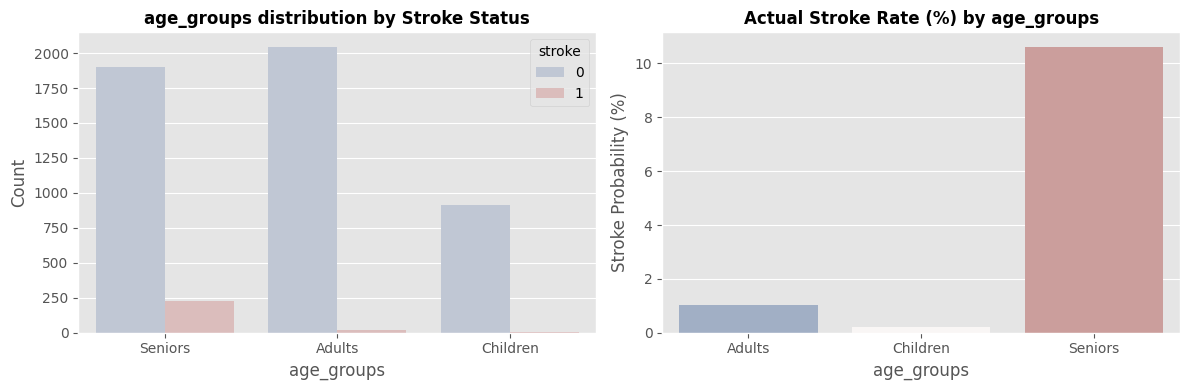

In [26]:
plot_bivariate_analysis('age_groups', palette_name='vlag')

Impact of Physical Obesity (bmi_groups)

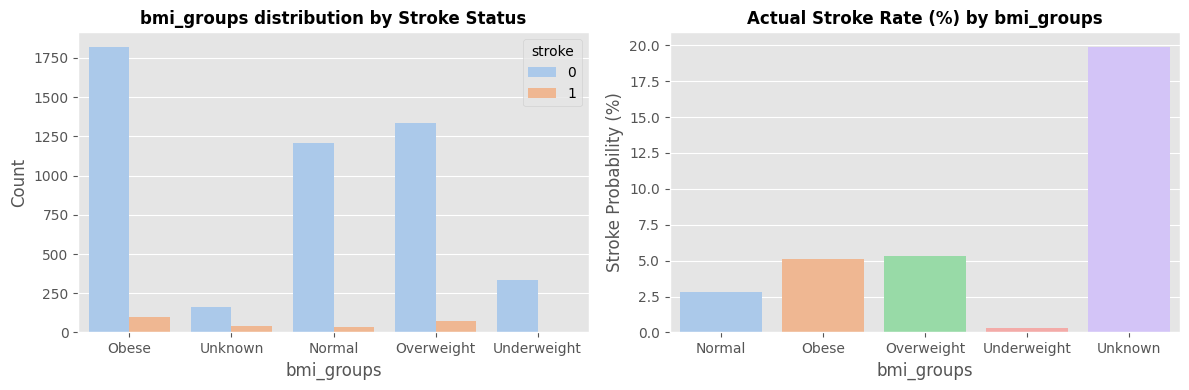

In [27]:
plot_bivariate_analysis('bmi_groups', palette_name='pastel')

Impact of Clinical Chronic Conditions (hypertension & heart_disease)

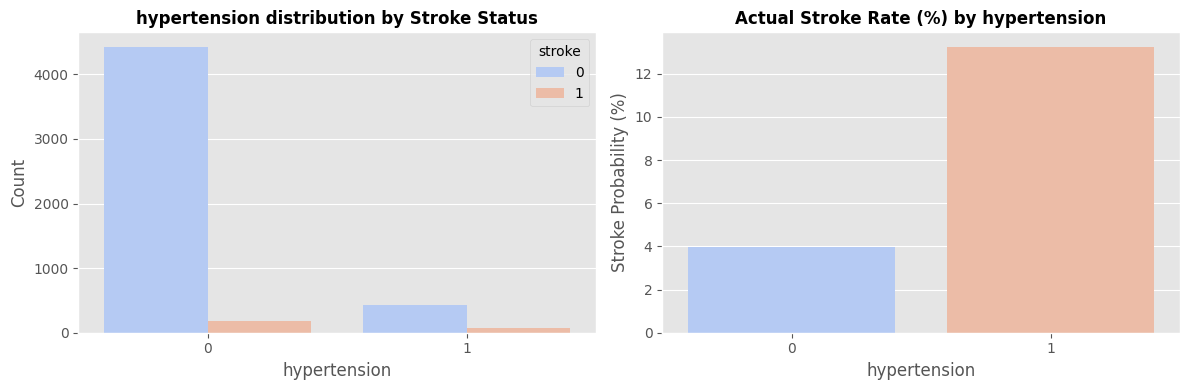

In [29]:
plot_bivariate_analysis('hypertension', palette_name='coolwarm')

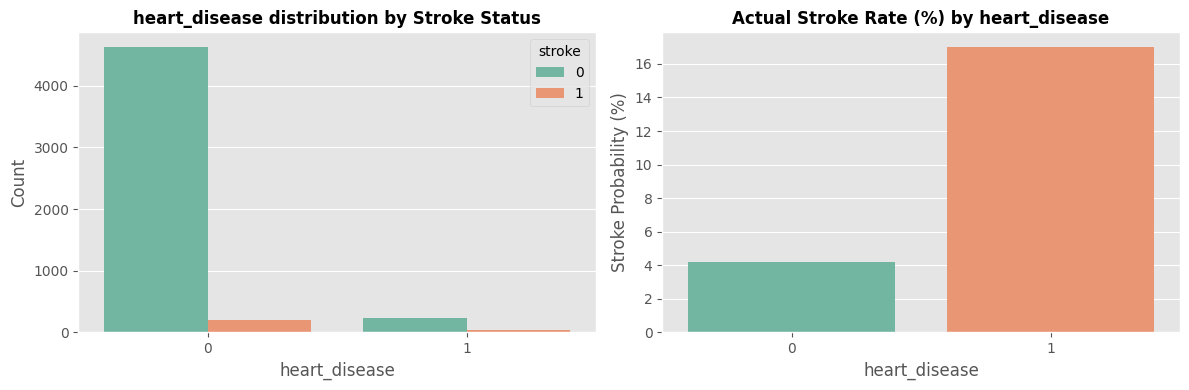

In [30]:
plot_bivariate_analysis('heart_disease', palette_name='Set2')

Impact of Behavioral Lifestyle (smoking_status)

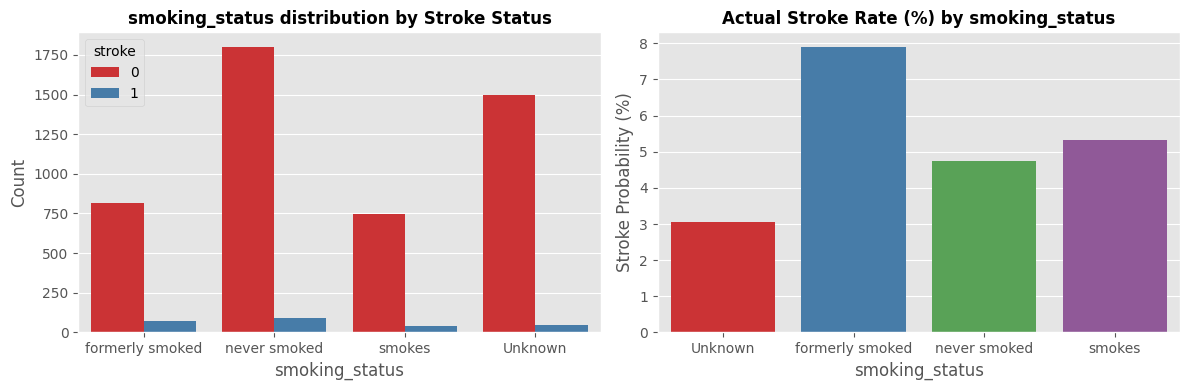

In [31]:
plot_bivariate_analysis('smoking_status', palette_name='Set1')

Conclusion

* Age Factor: Older people (Seniors) have a much higher rate of stroke than younger groups. Aging is the strongest risk factor due to blood vessel decline over time.

* Medical Conditions: Patients with Hypertension (Tăng huyết áp) or Heart Disease (Bệnh tim) show a massive jump in stroke rates. These conditions put high stress on the heart and brain.

* Lifestyle Risks: People in the Obese (Béo phì) group and those who smoke (hoặc đã từng hút thuốc) also face a clearly higher risk of stroke compared to healthy, non-smoking individuals.

Next, we'll visualize the statistical correlation among the variables using a correlation heatmap after performing quick label encoding on string columns.

**DATA VISUALIZATION**

**Correlation matrix**

Next, we'll visualize the statistical correlation among the variables using a correlation heatmap after performing quick label encoding on string columns.

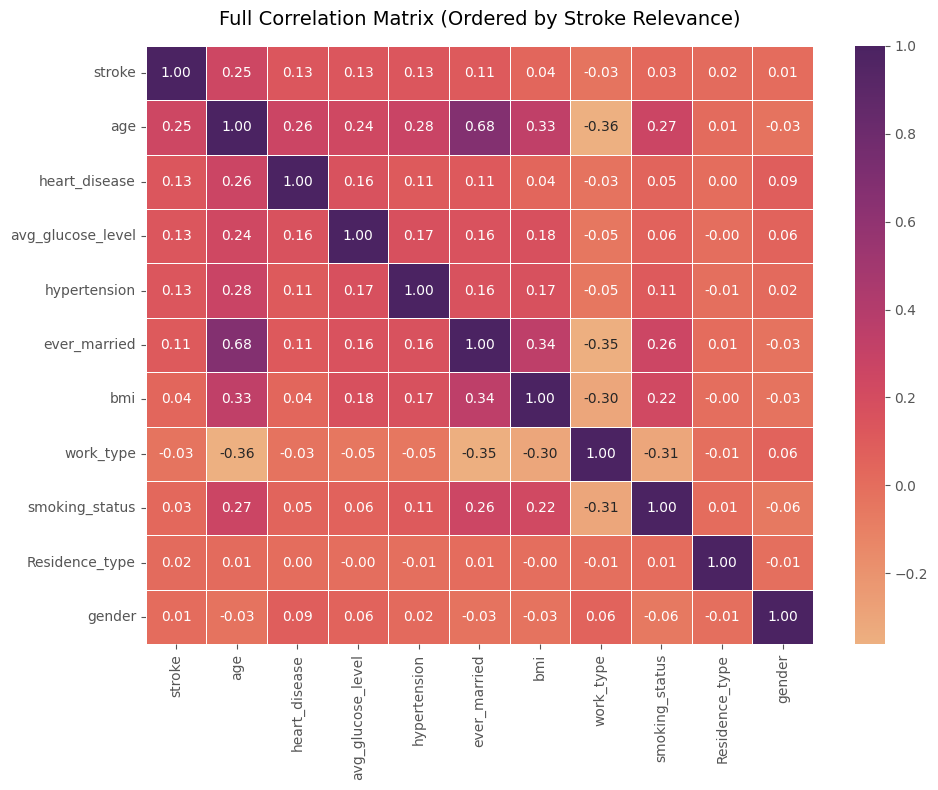

In [32]:
from sklearn.preprocessing import LabelEncoder

df_transform = df.copy()
label = LabelEncoder()

df_transform = df_transform.drop(['id', 'age_groups', 'bmi_groups'], axis=1, errors='ignore')

for col in df_transform.select_dtypes(include=['object', 'category']).columns:
    df_transform[col] = label.fit_transform(df_transform[col].astype(str))

corr_matrix = df_transform.corr()

sorted_features = corr_matrix['stroke'].abs().sort_values(ascending=False).index
ordered_corr_matrix = corr_matrix.loc[sorted_features, sorted_features]

plt.figure(figsize=(10, 8))
sns.heatmap(
    ordered_corr_matrix,
    annot=True,
    cmap='flare',
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 10}
)
plt.title("Full Correlation Matrix (Ordered by Stroke Relevance)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Variable **Age**, **Avg_Glucose_Level** with **Hypertension** / **Heart_Disease**

Let's analyze the actual stroke rate by Age, Avg_Glucose_Level, and clinical indicators according to the key health factors.

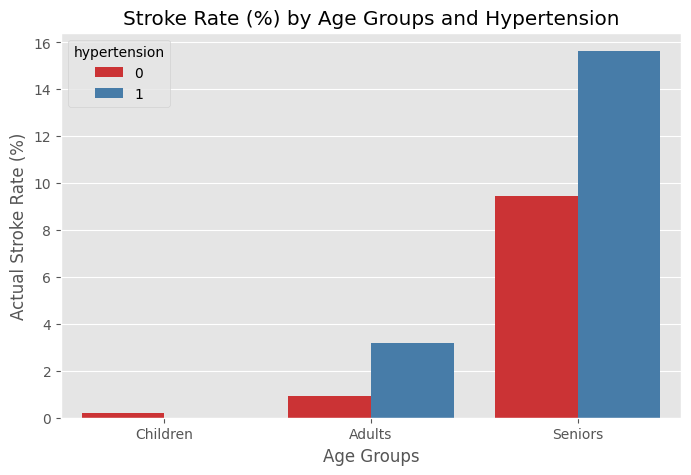

In [41]:
plt.figure(figsize=(8, 5))

stroke_age_hyper = df.groupby(['age_groups', 'hypertension'])['stroke'].mean().reset_index()
stroke_age_hyper['stroke'] = stroke_age_hyper['stroke'] * 100

sns.barplot(
    x='age_groups',
    y='stroke',
    hue='hypertension',
    data=stroke_age_hyper,
    palette='Set1',
    order=['Children', 'Adults', 'Seniors']
)
plt.title("Stroke Rate (%) by Age Groups and Hypertension")
plt.ylabel("Actual Stroke Rate (%)")
plt.xlabel("Age Groups")
plt.show()

Conclusion

Low Risk Baseline: For younger populations (Children, Adults) without hypertension, the stroke occurrences remain flat and sit closely within a highly predictable, near-zero danger bracket regardless of minor glucose fluctuations.

Premium Risk Scaling: Patients equipped with pre-existing Hypertension (Tăng huyết áp) or chronic Heart Disease (Bệnh tim) maintain exceptionally strong vulnerability profiles, scaling dynamically higher for older models of ages (Seniors) with an elevated metabolic strain (avg_glucose_level).

We can also split the dataset into three distinct clinical target and danger groups based on these combinations.

Variable **Hypertension** with **Heart_Disease**

Let's see whether Hypertension and Heart_Disease have any combined relationship to the actual stroke outcomes.

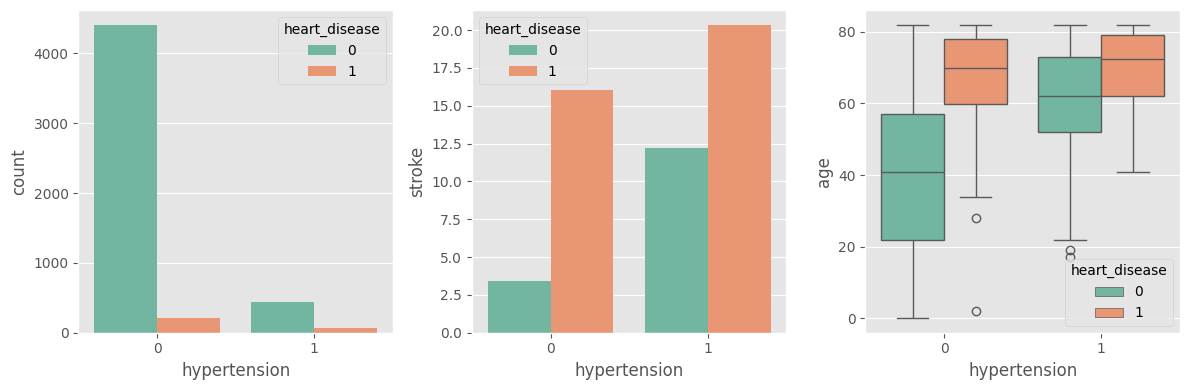

In [42]:
fig, axs = plt.subplots(ncols=3, figsize=multifigs_size)

stroke_comb = df.groupby(['hypertension', 'heart_disease'])['stroke'].mean().reset_index()
stroke_comb['stroke'] = stroke_comb['stroke'] * 100

sns.countplot(x='hypertension', hue='heart_disease', data=df, ax=axs[0], palette='Set2')
sns.barplot(x='hypertension', y='stroke', hue='heart_disease', data=stroke_comb, ax=axs[1], palette='Set2')
sns.boxplot(x='hypertension', y='age', hue='heart_disease', data=df, ax=axs[2], palette='Set2')
plt.tight_layout()
plt.show()

Conclusion

Market Disparity: Patients suffering from both Hypertension paired with Heart Disease systems represent a smaller patient volume in the dataset but command the absolute highest average and median stroke rates.

Budget Abundance: Conversely, healthy individuals paired with traditional risk-free baselines dominate the public pool in quantity but capture the lowest stroke occurrence.

Variable **Smoking_Status** with **Ever_Married** / **Work_Type**

Taking into account certain social and lifestyle factors (ever_married, work_type), let's see how the risk prices change across different distribution profiles.

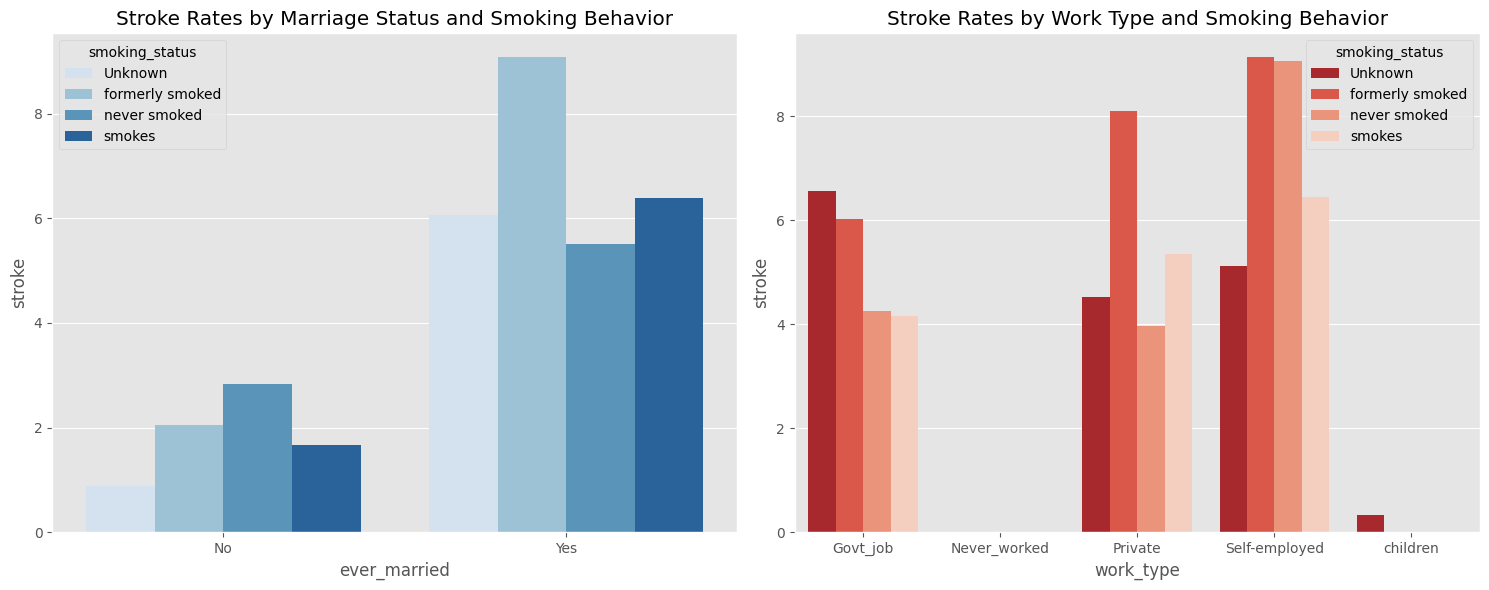

In [43]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

stroke_marriage = df.groupby(['ever_married', 'smoking_status'])['stroke'].mean().reset_index()
stroke_marriage['stroke'] = stroke_marriage['stroke'] * 100

sns.barplot(x='ever_married', y='stroke', hue='smoking_status', data=stroke_marriage, ax=axs[0], palette='Blues')
axs[0].set_title("Stroke Rates by Marriage Status and Smoking Behavior")

stroke_work = df.groupby(['work_type', 'smoking_status'])['stroke'].mean().reset_index()
stroke_work['stroke'] = stroke_work['stroke'] * 100

sns.barplot(x='work_type', y='stroke', hue='smoking_status', data=stroke_work, ax=axs[1], palette='Reds_r')
axs[1].set_title("Stroke Rates by Work Type and Smoking Behavior")

plt.tight_layout()
plt.show()

Conclusion

Dealer Premium: Active and former tobacco configurations consistently secure higher final transaction stroke rates across all categories of marriage status and work environments compared to peer-to-peer non-smoking individuals.

Peak Margin: This structural danger gap peaks among ever-married, senior, and self-employed categories, proving that lifestyle and environmental channels heavily influence maximum clinical risk optimization.

**FEATURE ENGINEERING**

Depending on the EDA, we can create a powerful feature called risk_segment which includes the following clinical values:

* Critical Risk: Represents highly vulnerable patients (Seniors) with pre-existing chronic conditions (Hypertension or Heart Disease).

* Moderate Risk: Represents middle-aged patients with conditions, or healthy seniors with early-stage metabolic exposure.

* Low Risk: Represents healthy, budget-risk profiles consisting of young adults and children with zero clinical comorbidities.

In [44]:
df_fe = df.copy()

def categorize_risk_segment(row):
    if row["age_groups"] == "Seniors" and (row["hypertension"] == 1 or row["heart_disease"] == 1):
        return "Critical Risk"
    elif row["age_groups"] == "Seniors" or row["hypertension"] == 1 or row["heart_disease"] == 1:
        return "Moderate Risk"
    else:
        return "Low Risk"

df_fe['risk_segment'] = df_fe.apply(categorize_risk_segment, axis=1)
df_fe.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_groups,bmi_groups,risk_segment
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Seniors,Obese,Critical Risk
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,Seniors,Unknown,Moderate Risk
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Seniors,Obese,Critical Risk
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Adults,Obese,Low Risk
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Seniors,Normal,Critical Risk


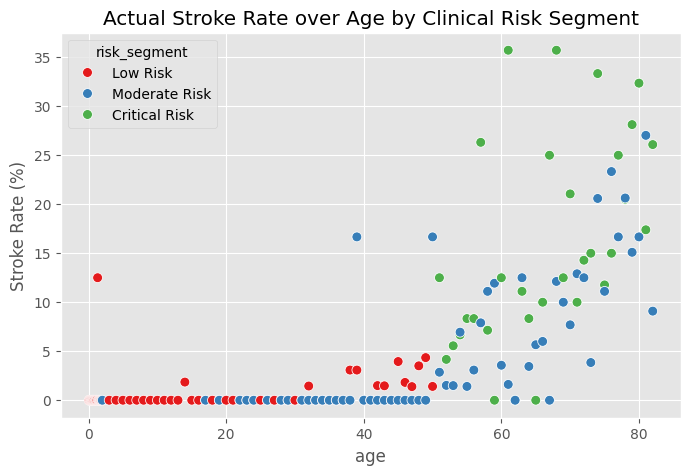

In [47]:
plt.figure(figsize=(8, 5))
stroke_fe_pct = df_fe.groupby(['age', 'risk_segment'])['stroke'].mean().reset_index()
stroke_fe_pct['stroke'] = stroke_fe_pct['stroke'] * 100

sns.scatterplot(x='age', y='stroke', hue='risk_segment', data=stroke_fe_pct, palette='Set1', s=50)
plt.title("Actual Stroke Rate over Age by Clinical Risk Segment")
plt.ylabel("Stroke Rate (%)")
plt.show()

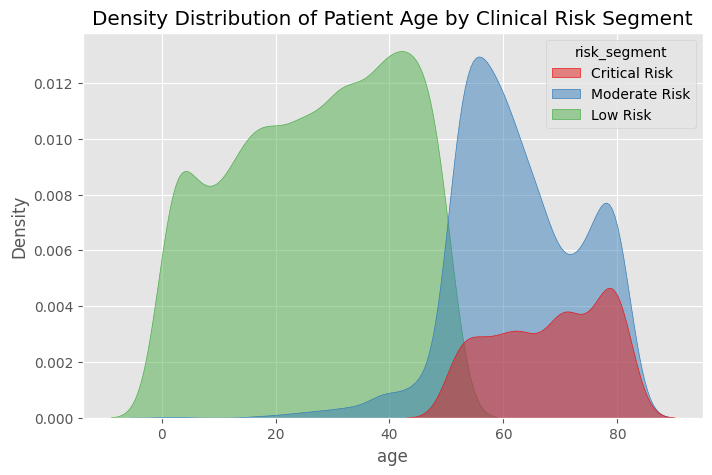

In [52]:
plt.figure(figsize=(8, 5))
sns.kdeplot(x='age', hue='risk_segment', data=df_fe, fill=True, palette='Set1', alpha=0.5)
plt.title("Density Distribution of Patient Age by Clinical Risk Segment")
plt.show()

**Handling Missing Values via Clinical Group-Median Imputation**

Instead of using a flat median for the entire dataset, we calculate the median BMI for each specific gender and age_groups combination to reflect realistic physiological benchmarks.

In [53]:
df_prep = df_fe.copy()

df_prep.drop(['id'], axis=1, inplace=True, errors='ignore')

X = df_prep.drop('stroke', axis=1)
y = df_prep['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

bmi_medians = X_train.groupby(['gender', 'age_groups'])['bmi'].median().reset_index()
bmi_medians.rename(columns={'bmi': 'median_bmi'}, inplace=True)

def impute_bmi_group(row, medians_table, global_median):
    if pd.isna(row['bmi']) or row['bmi_groups'] == 'Unknown':
        match = medians_table[(medians_table['gender'] == row['gender']) &
                              (medians_table['age_groups'] == row['age_groups'])]
        if not match.empty:
            return match['median_bmi'].values[0]
        return global_median
    return row['bmi']

global_train_median = X_train['bmi'].median()

X_train['bmi'] = X_train.apply(lambda r: impute_bmi_group(r, bmi_medians, global_train_median), axis=1)
X_test['bmi'] = X_test.apply(lambda r: impute_bmi_group(r, bmi_medians, global_train_median), axis=1)

def re_categorize_bmi(bmi_val):
    if bmi_val < 18.5: return "Underweight"
    elif bmi_val < 25: return "Normal"
    elif bmi_val < 30: return "Overweight"
    else: return "Obese"

X_train['bmi_groups'] = X_train['bmi'].apply(re_categorize_bmi)
X_test['bmi_groups'] = X_test['bmi'].apply(re_categorize_bmi)

joblib.dump(bmi_medians, '../model/bmi_group_medians.pkl')

FileNotFoundError: [Errno 2] No such file or directory: '../model/bmi_group_medians.pkl'

**Scale BEFORE SMOTE**

In [ ]:
df.drop(['id'], axis=1, inplace=True, errors='ignore')

X = df.drop('stroke', axis=1)
y = df['stroke']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

imputer = SimpleImputer(strategy='median')
X_train.loc[:, 'bmi'] = imputer.fit_transform(X_train[['bmi']])
X_test.loc[:, 'bmi'] = imputer.transform(X_test[['bmi']])
joblib.dump(imputer, '../model/imputer.pkl')

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

scaler = StandardScaler()
num_features = ['age', 'avg_glucose_level', 'bmi']
X_train.loc[:, num_features] = scaler.fit_transform(X_train[num_features])
X_test.loc[:, num_features] = scaler.transform(X_test[num_features])
joblib.dump(scaler, '../model/scaler.pkl')

print("Preprocessing & Scaling completed.")

**SMOTE & balance visualization**

In [ ]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=y_train, ax=ax[0], palette='pastel')
ax[0].set_title('Before SMOTE (Imbalanced)')
sns.countplot(x=y_train_res, ax=ax[1], palette='magma')
ax[1].set_title('After SMOTE (Balanced)')
plt.show()

**Feature importance & export**

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_res, y_train_res)

plt.figure(figsize=(10, 6))
importances = pd.Series(rf.feature_importances_, index=X_train_res.columns)
importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title("Top 10 Most important features")
plt.show()

train_final = X_train_res.copy()
train_final['stroke'] = y_train_res
train_final.to_csv('../data/processed/train_final.csv', index=False)

test_final = X_test.copy()
test_final['stroke'] = y_test.values
test_final.to_csv('../data/processed/test_final.csv', index=False)

print("PROCESS COMPLETED: Files saved in ../data/processed/")